# ICS - Travaux Pratiques 13

29.05.24


<font color=grey>_Dans ce 13e TP, nous allons continuer notre étude des méthodes d'approximation numérique d'intégrales définies. Nous reviendrons sur la différence entre une formule composite et non-composite et nous concentrerons sur une manière de placer les noeuds de manière à minimiser l'erreur sur l'intégrale, voire même d'obtenir un résultat exact._ 

_Note : ne vous sentez pas obligé.e.s de finir la série pendant la séance! Celle-ci est conçue de manière à ce que vous gardiez certains exercices pour vos révisions._ </font>

In [1]:
# importation des librairies numpy et matplotlib que nous allons utiliser dans ce notebook  
import numpy as np
import matplotlib.pyplot as plt

***

## Exercice 1 : Base de Lagrange

On considère la fonction $f(x)=x^3-2x+3$ qu'on aimerait interpoler par un polynôme en $x_0=-1$, $x_1=0$,  et $x_2=2$ en utilisant la base de Lagrange associée.

1) Calculer $y_i=f(x_i)$ :
- $f(x_0) = f(-1) = 4$
- $f(x_1) = f(0) = 3$
- $f(x_2) = f(2) = 7$

2) Construire les éléments $\varphi_i(x)$ de la base de Lagrange associée à ces trois points :
- $\\ \varphi_1(x) = \frac{1}{3} x^2 - \frac{2}{3} x \\$
- $\varphi_2(x) = -\frac{1}{2} x^2 + \frac{1}{2} x + 1 \\$
- $\varphi_3(x) = \frac{1}{6} x^2 + \frac{1}{6} x$

3) En extraire le polynôme d'interpolation $p(x)$:
$\\ p(x) = f(x_0) \cdot \varphi_1(x) + f(x_1) \cdot \varphi_2(x) + f(x_2) \cdot \varphi_3(x) \\$
$= \frac{4}{3} x^2 - \frac{8}{3} x + -\frac{3}{2} x^2 + \frac{3}{2} x + 3 + \frac{7}{6} x^2 + \frac{7}{6} \\$
$= x^2 + 3$

4) Représenter graphiquement sur le même graphe :
    - la fonction $f(x)$ en bleu et trait continu, 
    - le polynôme $p(x)$ en rouge et traitillés
    - les éléments de la base de Lagrange $\varphi_i(x)$ en traitillés et avec une transparence de 0.4 (on peut régler la transparence grâce au paramètre nommé `alpha` de la fonction `plot`)
    - une légende appropriée
4) Calculer l'erreur entre $f(x)$ et $p(x)$ en $x=1$. Comment expliquer cette erreur?
5) Admettons qu'on ait utilisé un quatrième point pour interpoler notre polynôme, disons $x_4=1$. Sans effectuer aucun calcul, quel aurait été le polynôme d'interpolation $p'(x)=\sum_i f(x_i)\varphi_i(x)$? => $p'(x)$ serait égal à $f(x)$ !

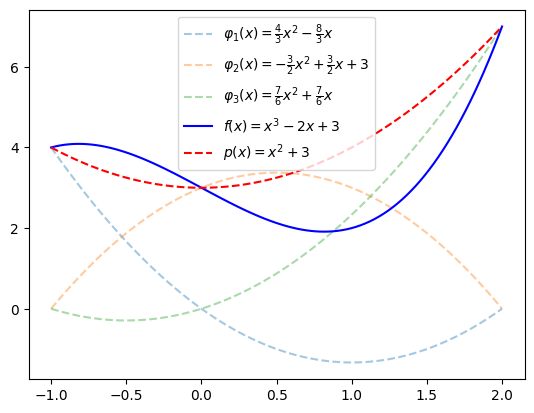

L'erreur en x_0 = 1 est de 2 entre f(x) et p(x) (f(1) = 2, p(1) = 4)
Puisque l'on cherche à approximer le graphe de f(x) avec seulement trois points, la précision est exacte jusqu'à une fonction de degré M - 1 = 2


In [4]:
# Réponse au point 4
def f(x):
    return x ** 3 - 2 * x + 3


def p(x):
    return x ** 2 + 3


def phi_1(x):
    return (4/3) * (x ** 2 - 2 * x) 


def phi_2(x):
    return -(3/2) * (x ** 2 - x - 2)


def phi_3(x):
    return (7/6) * (x ** 2 + x)


def error(f, p):
    return np.abs(f - p)


x = np.linspace(-1, 2, 100)

phi_1_ = phi_1(x)
phi_2_ = phi_2(x)
phi_3_ = phi_3(x)

f_ = f(x)
p_ = p(x)
error_1 = error(f(1), p(1))

plt.plot(x, phi_1_, "--", label=r"$\varphi_1(x) = \frac{4}{3} x^2 - \frac{8}{3} x$", alpha=.4)
plt.plot(x, phi_2_, "--", label=r"$\varphi_2(x) = -\frac{3}{2} x^2 + \frac{3}{2} x + 3$", alpha=.4)
plt.plot(x, phi_3_, "--", label=r"$\varphi_3(x) = \frac{7}{6} x^2 + \frac{7}{6} x$", alpha=.4)
plt.plot(x, f_, color="blue", label=r"$f(x) = x^3 - 2x + 3$")
plt.plot(x, p_, "r--", label=r"$p(x) = x^2 + 3$")

plt.legend()
plt.show()

print(f"L'erreur en x_0 = 1 est de {error_1} entre f(x) et p(x) (f(1) = {f(1)}, p(1) = {p(1)})",
      "Puisque l'on cherche à approximer le graphe de f(x) avec seulement trois points, la précision est exacte jusqu'à une fonction de degré M - 1 = 2", sep="\n")

***

## Exercice 2 : Application pratique des méthodes d'intégration

Au cours d'une expérience, on observe qu'un objet se déplaçant en ligne droite passe par l'origine du repère choisi en $t=0\,\text{s}$ avec une vitesse de $10\,\text{m/s}$. Ensuite, sa vitesse a été mesurée à différents instants et ces mesures ont été consignées dans un fichier `vitesse.txt`.

Dans cet exercice, il vous est demandé en particulier :
* d'importer les données de vitesse et de temps qui se trouvent dans le fichier texte `vitesse.txt` ;
* de représenter la vitesse de l'objet en fonction du temps en indiquant en rouge les points de mesure ;
* de calculer numériquement et **le plus précisément possible**, la distance parcourue par l'objet en fonction du temps, en supposant que la vitesse de l'objet **varie de manière régulière** entre deux points de mesure. On rappelle que $x(t) = \int_0^t v(t')\,dt'$;
* de représenter dans une même figure l'évolution de la vitesse de l'objet et de la distance parcourue par ce dernier depuis l'origine ;
* d'afficher à quelle distance de l'origine se trouve l'objet à l'instant où la dernière mesure a été effectuée.

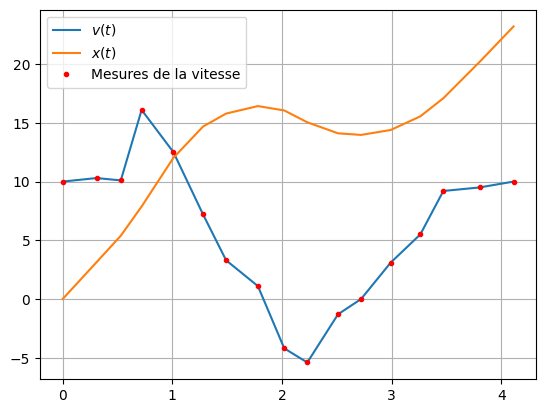

In [81]:
def distance(v, t):
    distance_lst = [0]
    for i in range(1, len(v)):
        distance_lst.append(distance_lst[i-1] + (v[i-1] + v[i]) / 2 * (t[i] - t[i-1]))
    return distance_lst


vitesse, temps = np.loadtxt("vitesse.txt", usecols=(0,1), skiprows=4, unpack=True)

distance_ = distance(vitesse, temps)

plt.plot(temps, vitesse, label=r"$v(t)$")
plt.plot(temps, distance_, label=r"$x(t)$")
plt.plot(temps, vitesse, "r.", label="Mesures de la vitesse")
plt.legend()
plt.grid()
plt.show()

***

## Exercice 3 : Méthodes du point milieu, du trapèze, de Simpson

Dans cet exercice, il vous est demandé de :
 * calculer numériquement l'intégrale définie
 $$
 I = \int_{0}^{\pi/2}{\sin{(x)} \,dx}
 $$
 
 à l'aide des **méthodes du point milieu et du trapèze** avec une partition de $5$ sous-intervalles (vous pouvez adapter le code des exercices du TP précédent). C'est-à-dire, calculez l'approximation de l'intégrale **pour chaque sous-intervalle**, puis sommez ces valeurs pour obtenir l'approximation finale ; 
 * comparer les valeurs obtenues à la vraie valeur de l'intégrale définie $I$ (calculée analytiquement) ;
 * vérifier qu'une combinaison des deux méthodes avec des poids respectifs de $2/3$ et $1/3$ permet d'améliorer significativement le calcul numérique ; 
 * vérifier analytiquement que cette combinaison correspond en fait à la **méthode de Simpson**. Pour simplifier les calculs, on peut considérer qu'un seul intervalle $[a,b]$.

In [52]:
def milieu(f, a, b):
    return (b-a) * f((b+a)/2)


def trapeze(f, a, b):
    return (f(b) + f(a)) / 2 * (b-a)


def f(x):
    return np.sin(x)
    

def integral(f, a, b, n):
    b_ = a
    dx = (b-a) / n
    
    milieu_ = 0
    trapeze_ = 0
    
    for i in range(1, n + 1):
        a_ = b_
        b_ = a_ + dx
        milieu_ += milieu(f, a_, b_)
        trapeze_ += trapeze(f, a_, b_)
    
    return (trapeze_, milieu_)


a = 0
b = np.pi / 2
n = 5

calcul_num = -np.cos(b) + np.cos(a)
calcul_trap, calcul_milieu = integral(f, a, b, n)

print(calcul_num, calcul_milieu, calcul_trap)
print(calcul_num, calcul_milieu * (2 / 3) + calcul_trap * (1 / 3))


0.9999999999999999 1.004124203953987 0.9917617687547273
0.9999999999999999 1.0000033922209004


***

## Exercice 4 : Exactitude de la méthode de Simpson

En sachant que :
- $t_1=-1$, $t_2=0$ et $t_3=1$, ainsi que :
- $\omega_1=\frac{1}{3}$, $\omega_2=\frac{4}{3}$ et $\omega_3 = \frac{1}{3}$, 

montrez analytiquement que la méthode de Simpson est exacte pour tout polynôme de degré 3.

***

## Exercice 5 : Méthode de Simpson composite 

Dans cet exercice, nous allons nous intéresser à la fonction :

$$
f(x) = x^x \,.
$$

Cette fonction n'est définie que pour $x>0$ et n'admet pas de primitive pouvant être écrite en terme de fonctions simples.

Plus précisément, il vous est demandé de :
 * représenter la fonction $f(x)$ sur l'intervalle $]0,2]$, avec des valeurs allant de $0$ à $2$ en abscisse et de $0$ à $4$ en ordonnée ;
 * calculer numériquement l'intégrale définie $I = \int_{0}^{2}{f(x) dx}$. Pour ce faire, il vous est demandé de :
     * définir une fonction Python `integration_Simpson` admettant comme arguments : la fonction `f` à intégrer, les bornes `a` et `b` de l'intervalle d'intégration et le nombre `n` de sous-intervalles considérés ; cette fonction devra utiliser la **méthode de Simpson** (composite) ;
     * calculer l'intégrale définie $I$ à l'aide de cette fonction Python en considérant une **partition avec 100 sous-intervalles** ;
     * donner une estimation de la précision de la méthode avec cette partition de $100$ sous-intervalles en la comparant avec une partition de $101$ sous-intervalles. 

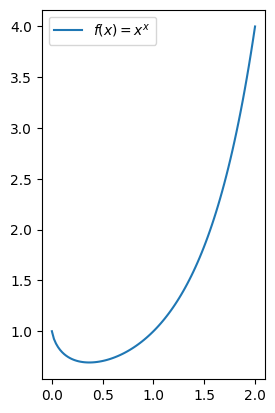

J_100:  2.833884625716644 | J_101:  2.833884469081482
Il y a donc une précision de | J_101 - J_100 | = 1.5663516217401252e-07


In [73]:
def f(x):
    return np.pow(x, x)


def integration_Simpson(f, a, b, n):
    borne_max = a
    dx = (b-a) / n
    J = 0
    
    for _ in range(1, n+1):
        borne_min = borne_max
        borne_max = borne_min + dx
        
        J += (borne_max - borne_min) / 6 * (f(borne_min) + 4 * f((borne_max + borne_min) / 2) + f(borne_max))
    
    return J
        

x = np.linspace(0, 2, 100)

plt.plot(x, f(x), label=r"$f(x) = x^x$")
plt.legend(loc="best")
plt.axis('scaled')
plt.show()

simpson = integration_Simpson(f, 0, 2, 100)
simpson_bis = integration_Simpson(f, 0, 2, 101)
print("J_100: ", simpson, "| J_101: ", simpson_bis)
print(f"Il y a donc une précision de | J_101 - J_100 | = {np.abs(simpson-simpson_bis)}")